# Gradient Descent for Linear Regression

A from-scratch implementation of (stochastic) gradient descent for linear regression, plus experiments with the loss function, learning rate schedule, and regularization -- capped off with a simulated annealing comparison.

This notebook implements gradient descent for linear regression from scratch, then explores how it behaves under different hyperparameters and loss functions.

In [1]:
from typing import List, Iterable

import numpy as np
import matplotlib.pyplot as plt

## Part 1: Gradient Descent

As a starting point, here's the simplest error functional used for regression -- Mean Squared Error:

$$
Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell (\langle x_i, w \rangle - y_i)^2
$$

where $x_i$ is the $i$-th object in the dataset, $y_i$ is its true target, and $w$ are the weights of the linear model.

For a linear model, this can be written in matrix form:

$$
Q(w, X, y) = \frac{1}{\ell} || Xw - y ||^2
$$

where $X$ is the objects-by-features matrix and $y$ is the vector of targets.

To run gradient descent I need the gradient of this functional. For MSE it works out to:

$$
\nabla_w Q(w, X, y) = \frac{2}{\ell} X^T(Xw-y)
$$

Below is a base `BaseLoss` class that every loss I implement will subclass. It defines two abstract methods:
1. `calc_loss`, which takes objects `x`, targets `y`, and weights `w`, and returns the loss value
2. `calc_grad`, which takes the same inputs and returns the gradient (a vector)

In [2]:
import abc

class BaseLoss(abc.ABC):
    """Base loss class"""
    @abc.abstractmethod
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Computes the loss value
        :param X: np.ndarray of shape (n_objects, n_features) -- the dataset's objects
        :param y: np.ndarray of shape (n_objects,) -- the true targets
        :param w: np.ndarray of shape (n_features,) -- the linear regression weights
        :return: a number -- the loss value
        """
        raise NotImplementedError

    @abc.abstractmethod
    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Computes the gradient of the loss with respect to weights w
        :param X: np.ndarray of shape (n_objects, n_features) -- the dataset's objects
        :param y: np.ndarray of shape (n_objects,) -- the true targets
        :param w: np.ndarray of shape (n_features,) -- the linear regression weights
        :return: np.ndarray of shape (n_features,) -- the gradient of the loss w.r.t. w
        """
        raise NotImplementedError

Now let's implement this abstract class: the Mean Squared Error loss.

Implement `MSELoss`, computing the loss and gradient from the formulas above.

In [3]:
class MSELoss(BaseLoss):
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Computes the loss value
        :param X: np.ndarray of shape (n_objects, n_features) -- the dataset's objects
        :param y: np.ndarray of shape (n_objects,) -- the true targets
        :param w: np.ndarray of shape (n_features,) -- the linear regression weights
        :return: a number -- the loss value
        """
        return np.square(np.dot(X,w) - y).mean()

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Computes the gradient of the loss with respect to weights w
        :param X: np.ndarray of shape (n_objects, n_features) -- the dataset's objects
        :param y: np.ndarray of shape (n_objects,) -- the true targets
        :param w: np.ndarray of shape (n_features,) -- the linear regression weights
        :return: np.ndarray of shape (n_features,) -- the gradient of the loss w.r.t. w
        """
        return 2 / np.size(y) * np.dot(np.matrix.transpose(X) , (np.dot(X, w) - y))

Now I can create an `MSELoss` object and use it to compute the loss value and gradient:

In [4]:
# create the loss object
loss = MSELoss()

# create a toy dataset
X = np.arange(200).reshape(20, 10)
y = np.arange(20)

# create a weight vector
w = np.arange(10)

# print the loss and gradient on this dataset with this weight vector
print(loss.calc_loss(X, y, w))
print(loss.calc_grad(X, y, w))

# sanity check that the methods are implemented correctly
assert loss.calc_loss(X, y, w) == 27410283.5, "calc_loss is implemented incorrectly"
assert np.allclose(loss.calc_grad(X, y, w), np.array([1163180., 1172281., 1181382., 1190483.,
                                                      1199584., 1208685., 1217786., 1226887.,
                                                     1235988., 1245089.])), "calc_grad is implemented incorrectly"
print("All correct!")

27410283.5
[1163180. 1172281. 1181382. 1190483. 1199584. 1208685. 1217786. 1226887.
 1235988. 1245089.]
All correct!


Now that I can compute gradients, let's write the actual gradient descent loop. Recall that a single gradient descent update looks like:

$$
w^t = w^{t-1} - \eta \nabla_{w} Q(w^{t-1}, X, y)
$$

where $w^t$ is the weight vector at iteration $t$, and $\eta$ is the learning rate controlling the step size.

Implement `gradient_descent`.

It should take the initial weights `w_init`, the feature matrix `X`, the target vector `y`, a `loss` object, a step size `lr`, and a number of iterations `n_iterations`. Each iteration takes one gradient step (gradients come from `loss.calc_grad`) using the formula above, and the function returns the full descent trajectory (the list of weight values at each step).

In [5]:
def gradient_descent(w_init: np.ndarray, X: np.ndarray, y: np.ndarray,
                        loss: BaseLoss, lr: float, n_iterations: int = 100000) -> List[np.ndarray]:
    """
    Gradient descent
    :param w_init: np.ndarray of shape (n_feratures,) -- initial weight vector
    :param X: np.ndarray of shape (n_objects, n_features) -- objects-by-features matrix
    :param y: np.ndarray of shape (n_objects,) -- vector of true targets
    :param loss: an instance of a BaseLoss subclass, computes gradients via loss.calc_grad(X, y, w)
    :param lr: float -- step size to scale the gradient by
    :param n_iterations: int -- number of iterations to run
    :return: list of n_iterations np.ndarray objects of shape (n_features,) -- weight history at each step
    """
    ans_traj = []
    ans_traj.append(w_init)
    for i in range(n_iterations):
        w_new = w_init - lr * loss.calc_grad(X, y, w_init)
        ans_traj.append(w_new)
        w_init = w_new
    return ans_traj

Now let's build a synthetic dataset and a helper to plot the gradient descent trajectory:

In [6]:
# build a two-feature dataset with a known ground-truth weight vector w_true

np.random.seed(1337)

n_features = 2
n_objects = 300
batch_size = 10
num_steps = 43

w_true = np.random.normal(size=(n_features, ))

X = np.random.uniform(-5, 5, (n_objects, n_features))
X *= (np.arange(n_features) * 2 + 1)[np.newaxis, :]
y = X.dot(w_true) + np.random.normal(0, 1, (n_objects))
w_init = np.random.uniform(-2, 2, (n_features))
print(X.shape)
print(w_init.shape)
print(y.shape)

(300, 2)
(2,)
(300,)


In [7]:
loss = MSELoss()
w_list = gradient_descent(w_init, X, y, loss, 0.01, 100)
print(loss.calc_loss(X, y, w_list[0]))
print(loss.calc_loss(X, y, w_list[-1]))

425.58917680450253
0.8670644395649493


In [10]:
def plot_gd(w_list: Iterable, X: np.ndarray, y: np.ndarray, loss: BaseLoss):
    """
    Plots the gradient descent trajectory
    :param w_list: list of np.ndarray of shape (n_features,) -- weight history at each step
    :param X: np.ndarray of shape (n_objects, n_features) -- objects-by-features matrix
    :param y: np.ndarray of shape (n_objects,) -- vector of true targets
    :param loss: an instance of a BaseLoss subclass, computes the loss via loss.calc_loss(X, y, w)
    """
    w_list = np.array(w_list)
    meshgrid_space = np.linspace(-2, 2, 100)
    A, B = np.meshgrid(meshgrid_space, meshgrid_space)

    levels = np.empty_like(A)
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            w_tmp = np.array([A[i, j], B[i, j]])
            levels[i, j] = loss.calc_loss(X, y, w_tmp)

    plt.figure(figsize=(15, 6))
    plt.title("GD trajectory")
    plt.xlabel(r'$w_1$')
    plt.ylabel(r'$w_2$')
    plt.xlim(w_list[:, 0].min() - 0.1,
             w_list[:, 0].max() + 0.1)
    plt.ylim(w_list[:, 1].min() - 0.1,
             w_list[:, 1].max() + 0.1)
    plt.gca().set_aspect('equal')

    # visualize the level set
    CS = plt.contour(A, B, levels, levels=np.logspace(0, 1, num=20), cmap=plt.cm.rainbow_r)
    CB = plt.colorbar(CS, shrink=0.8, extend='both')

    # visualize trajectory
    plt.scatter(w_list[:, 0], w_list[:, 1])
    plt.plot(w_list[:, 0], w_list[:, 1])

    plt.show()

Using `gradient_descent` and `plot_gd`, plot the descent trajectory for a few different learning rates (`lr`) -- at least four values -- and see how the step size affects convergence behavior. Good values to try: somewhere between 0.0001 and 0.1.

l= 0.0001


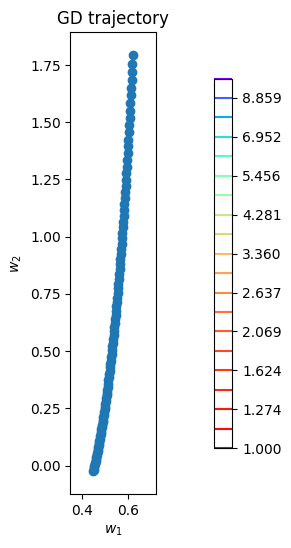

l= 0.0005


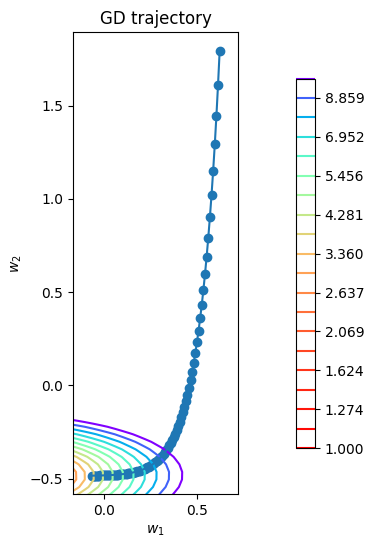

l= 0.001


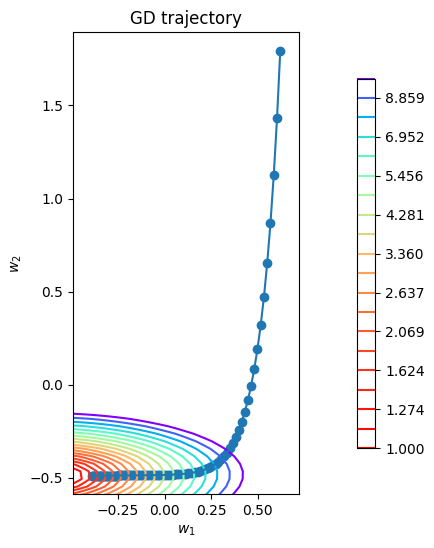

l= 0.005


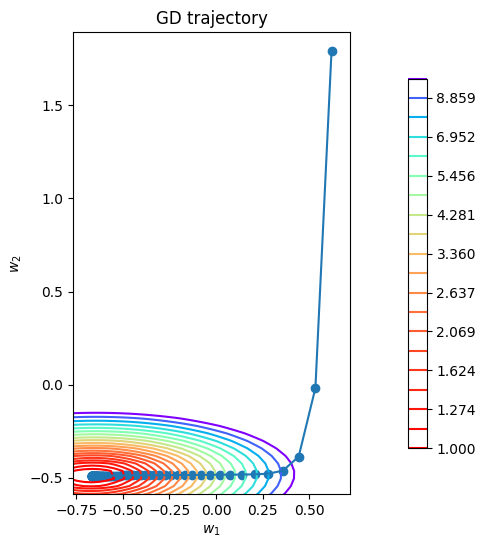

l= 0.01


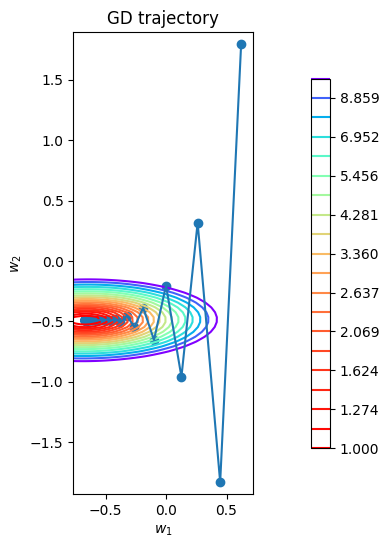

l= 0.1


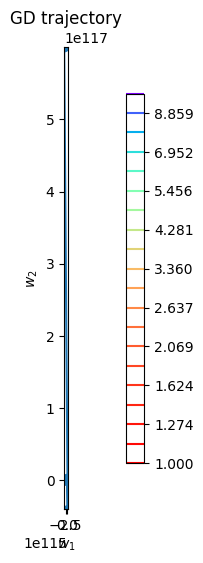

In [11]:
#Takeaway: with too small a step size, gradient descent doesn't have time to converge
#With a slightly larger step size than optimal, it oscillates noticeably but still converges
#With too large a step size, gradient descent can overshoot the minimum entirely.
l = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.1]
for elem in l:
    print('l=', elem)
    plot_gd(gradient_descent(w_init, X, y, loss, elem, 100), X, y ,loss)

Now let's implement stochastic gradient descent.

Implement `stochastic_gradient_descent`.

Same signature as `gradient_descent`, plus a `batch_size` parameter. Each step computes the gradient on a randomly sampled subset of `X` rather than the full dataset.

`np.random.choice` works well for sampling a random batch of indices:
```
batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
batch = X[batch_indices]
```

In [12]:
def stochastic_gradient_descent(w_init: np.ndarray, X: np.ndarray, y: np.ndarray,
                        loss: BaseLoss, lr: float, batch_size: int, n_iterations: int = 1000) -> List[np.ndarray]:
    """
    Gradient descent
    :param w_init: np.ndarray of shape (n_feratures,) -- initial weight vector
    :param X: np.ndarray of shape (n_objects, n_features) -- objects-by-features matrix
    :param y: np.ndarray of shape (n_objects,) -- vector of true targets
    :param loss: an instance of a BaseLoss subclass, computes gradients via loss.calc_grad(X, y, w)
    :param lr: float -- step size to scale the gradient by
    :param batch_size: int -- size of the mini-batch to sample at each step
    :param n_iterations: int -- number of iterations to run
    :return: list of n_iterations np.ndarray objects of shape (n_features,) -- weight history at each step
    """
    ans_traj = []
    ans_traj.append(w_init)
    for i in range(n_iterations):
        batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
        batch = X[batch_indices]
        w_new = w_init - lr * loss.calc_grad(batch, y[batch_indices], w_init)
        ans_traj.append(w_new)
        w_init = w_new
    return ans_traj

Using `stochastic_gradient_descent` and `plot_gd`, plot descent trajectories for different combinations of learning rate (`lr`) and batch size (`batch_size`) -- at least four values each. How do `lr` and `batch_size` affect SGD's behavior, and how does it compare to full-batch gradient descent?

Note: the dataset only has 300 objects, so `batch_size` values above that don't make sense.

l= 0.0001
batch_size= 3


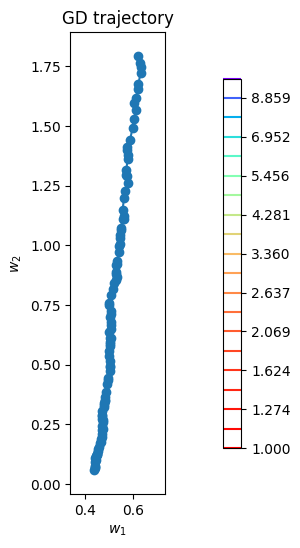

l= 0.0001
batch_size= 5


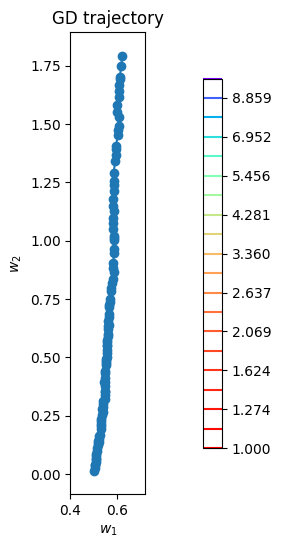

l= 0.0001
batch_size= 10


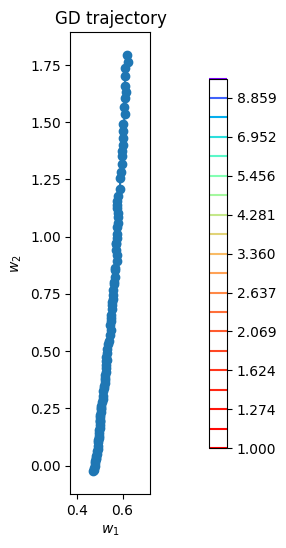

l= 0.0001
batch_size= 25


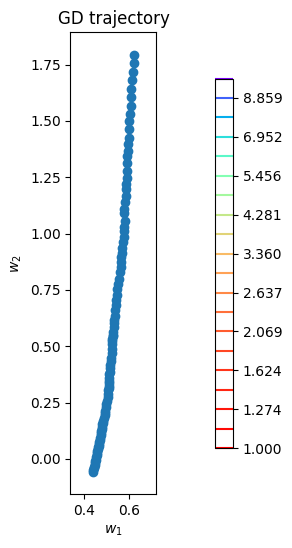

l= 0.0001
batch_size= 50


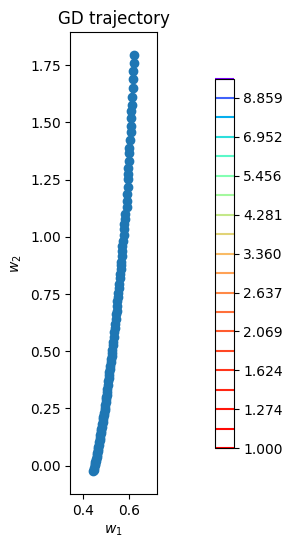

l= 0.0001
batch_size= 100


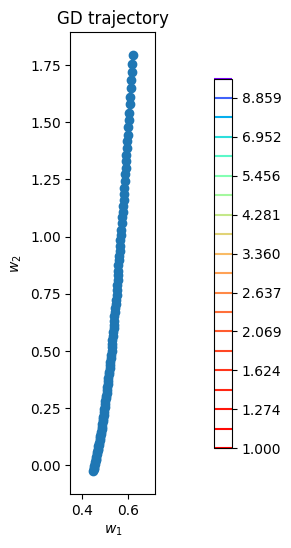

l= 0.0005
batch_size= 3


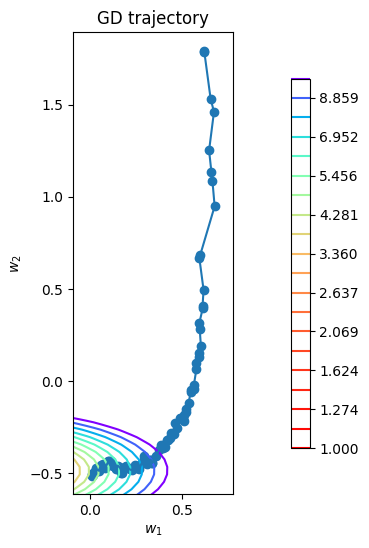

l= 0.0005
batch_size= 5


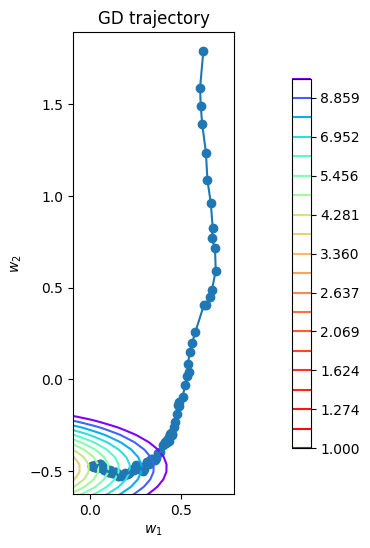

l= 0.0005
batch_size= 10


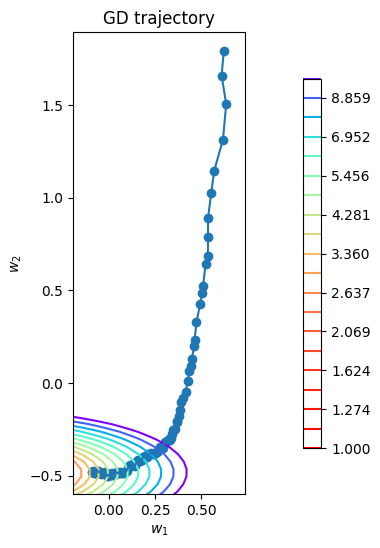

l= 0.0005
batch_size= 25


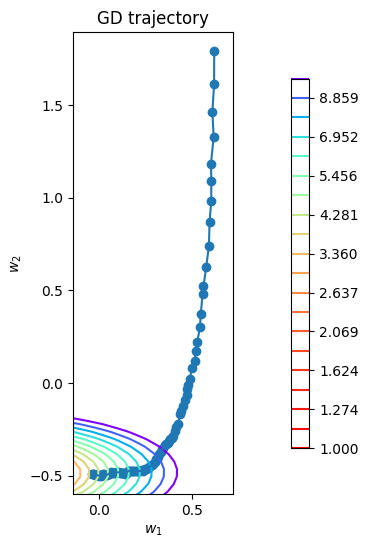

l= 0.0005
batch_size= 50


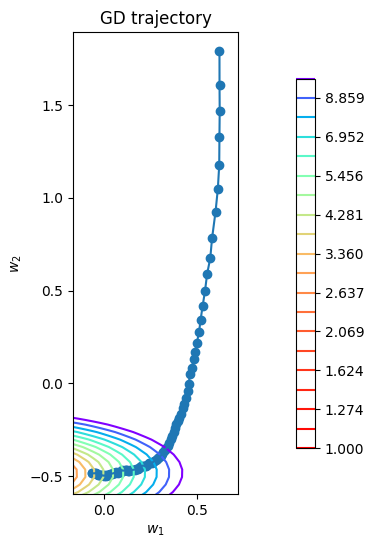

l= 0.0005
batch_size= 100


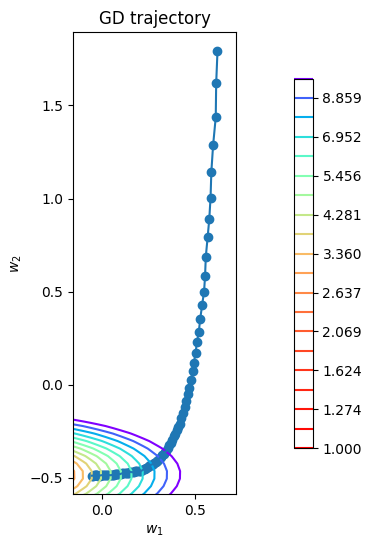

l= 0.001
batch_size= 3


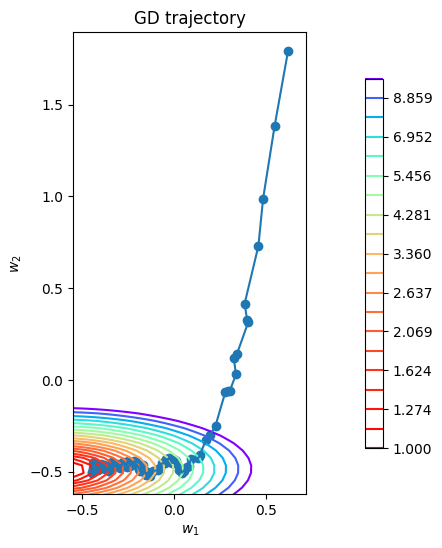

l= 0.001
batch_size= 5


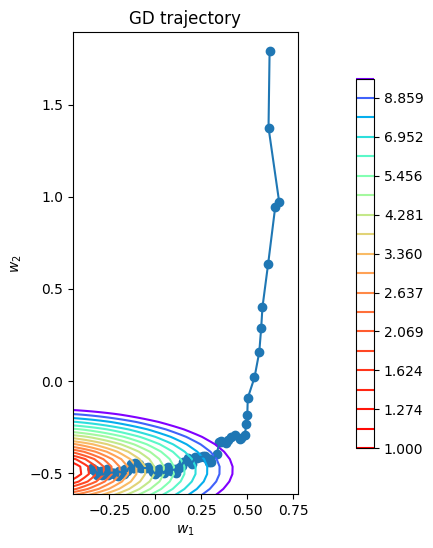

l= 0.001
batch_size= 10


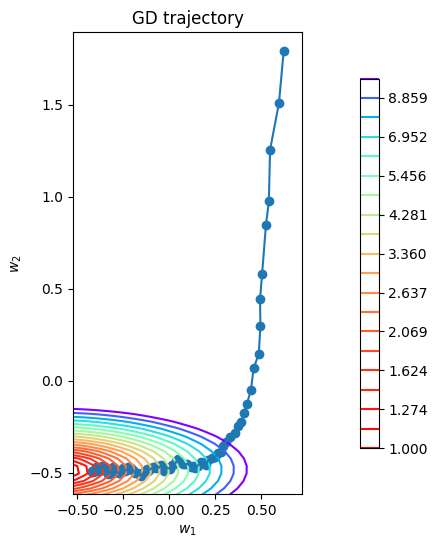

l= 0.001
batch_size= 25


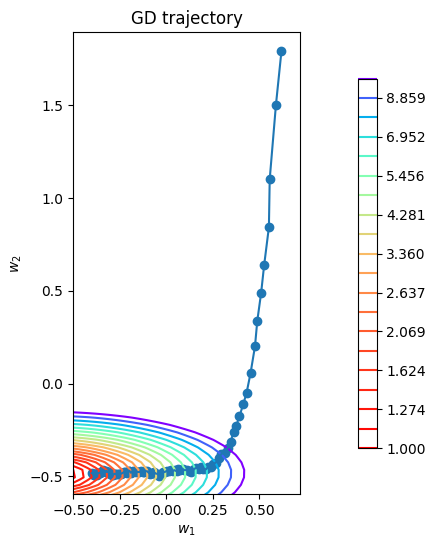

l= 0.001
batch_size= 50


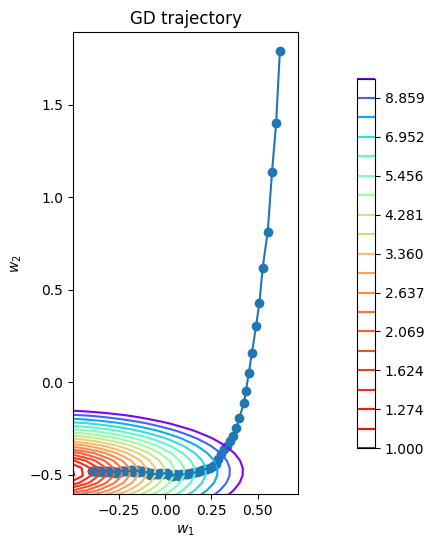

l= 0.001
batch_size= 100


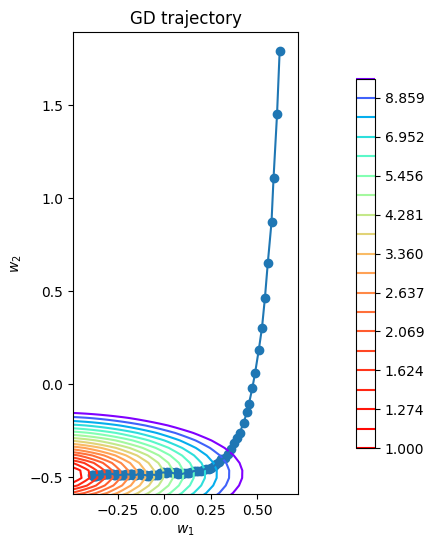

l= 0.005
batch_size= 3


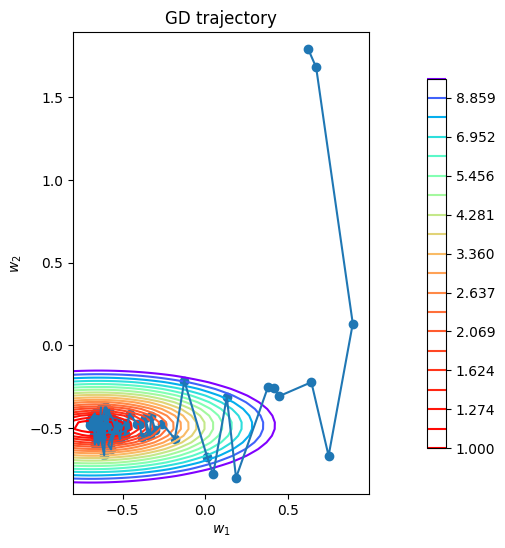

l= 0.005
batch_size= 5


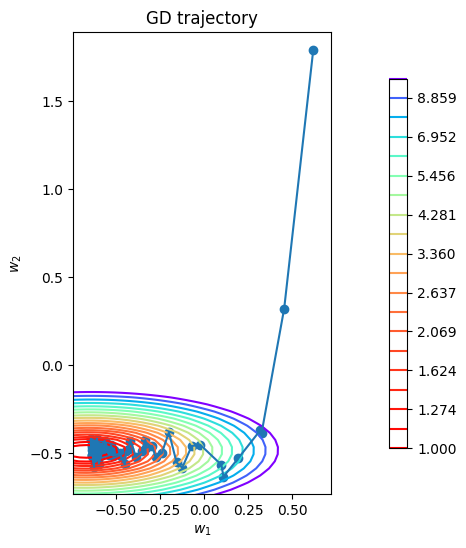

l= 0.005
batch_size= 10


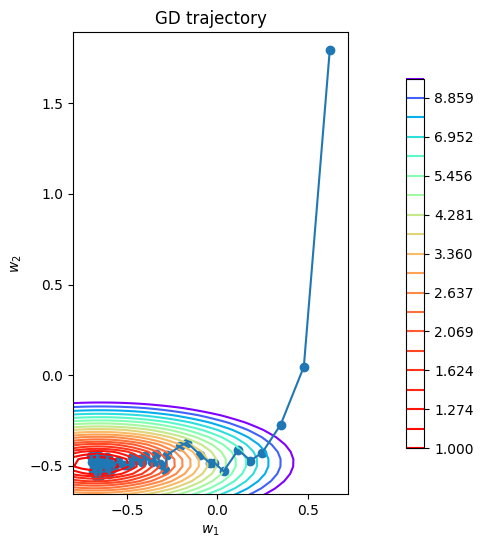

l= 0.005
batch_size= 25


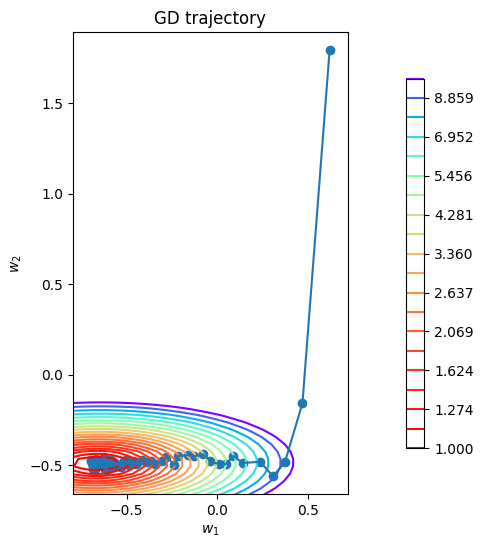

l= 0.005
batch_size= 50


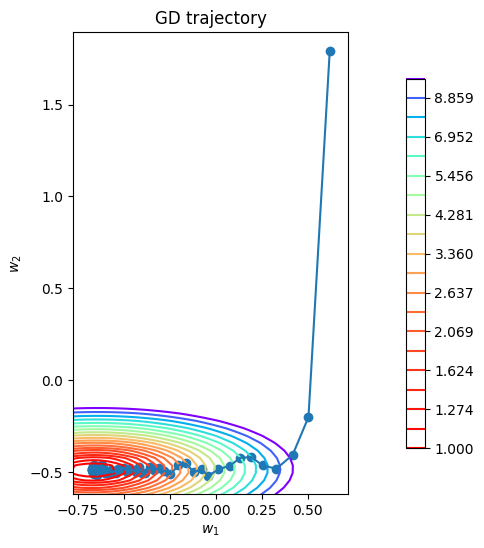

l= 0.005
batch_size= 100


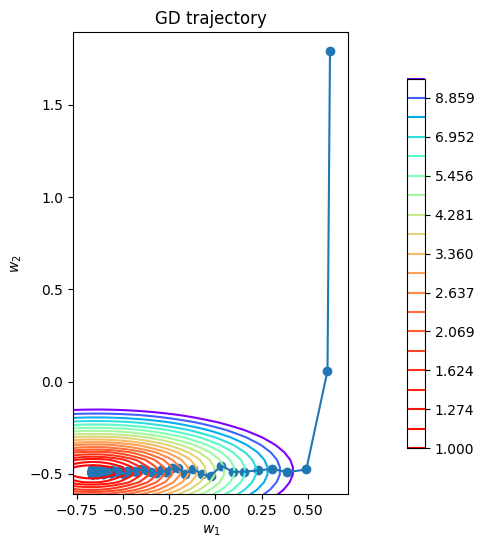

l= 0.01
batch_size= 3


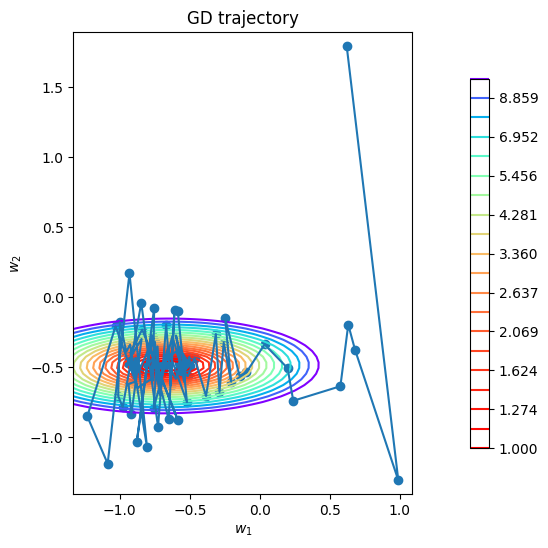

l= 0.01
batch_size= 5


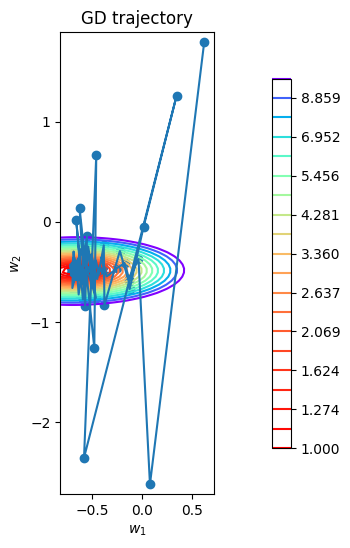

l= 0.01
batch_size= 10


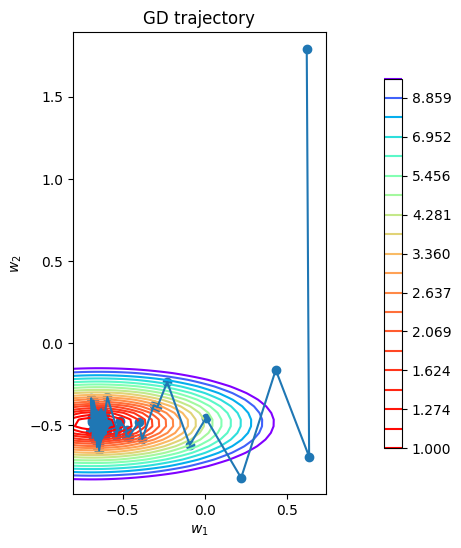

l= 0.01
batch_size= 25


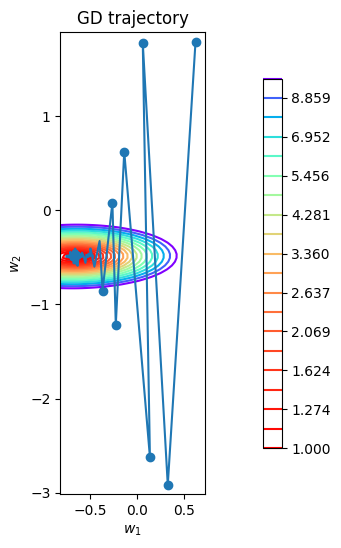

l= 0.01
batch_size= 50


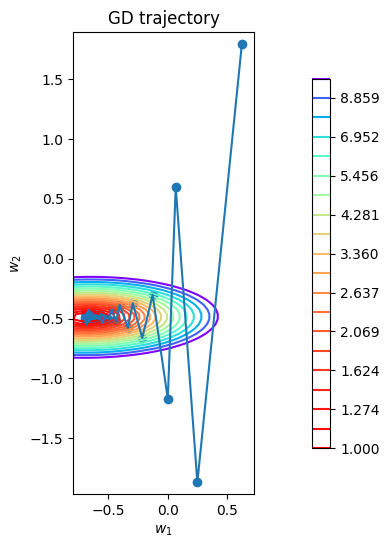

l= 0.01
batch_size= 100


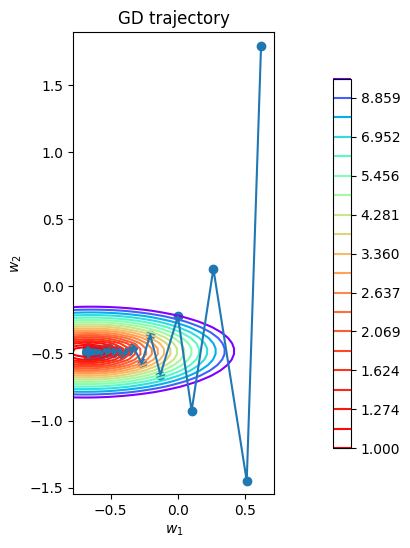

l= 0.1
batch_size= 3


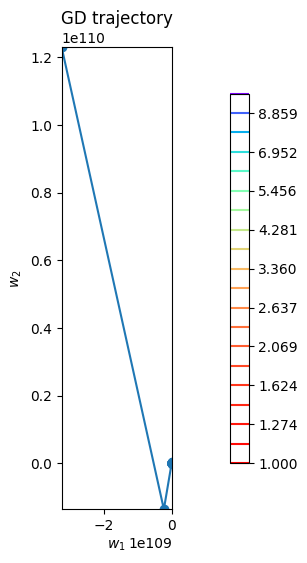

l= 0.1
batch_size= 5


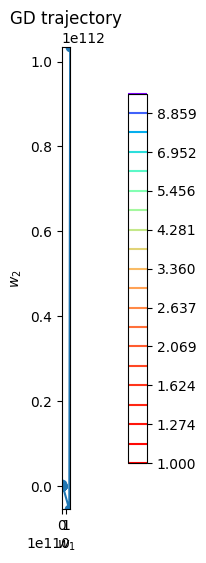

l= 0.1
batch_size= 10


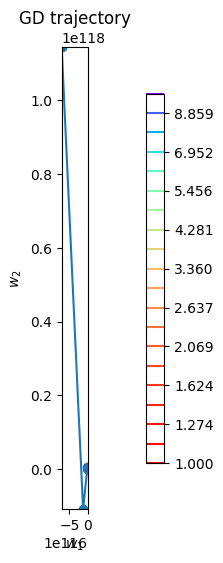

l= 0.1
batch_size= 25


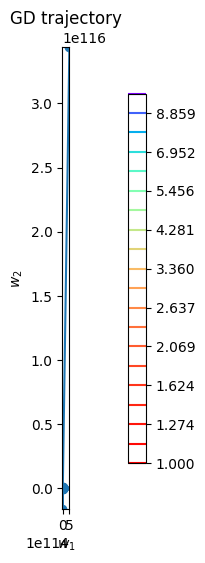

l= 0.1
batch_size= 50


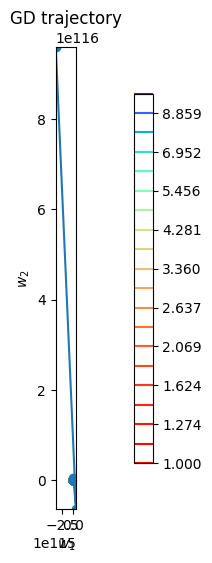

l= 0.1
batch_size= 100


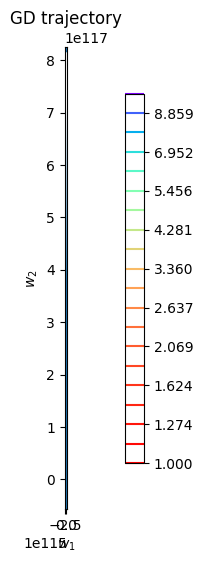

In [13]:
#Takeaway: with too small a learning rate, regardless of batch_size, SGD doesn't converge in time
# With a slightly larger learning rate and a small batch_size, the descent starts moving in different
# directions -- the overall motion is orderly but still noisy
# The larger the batch_size, the smaller the oscillation (less noise)
# With too large a learning rate, descent may fail to converge at all
l = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.1]
batch_size = [3, 5, 10, 25, 50, 100]
for elem in l:
    for el in batch_size:
        print('l=', elem)
        print('batch_size=', el)
        plot_gd(stochastic_gradient_descent(w_init, X, y, loss, elem, el,  100), X, y ,loss)

You've probably noticed that gradient descent's behavior, especially the stochastic version, depends heavily on the step size.

Typically, early in training I want large steps to approach the minimum quickly, and later I want small steps to home in on it precisely without overshooting.

One way to get that behavior is to shrink the step size as the iteration count grows, e.g. using:

$$
    \eta_t
    =
    \lambda
    \left(
        \frac{s_0}{s_0 + t}
    \right)^p
$$

where $\eta_t$ is the step size at iteration $t$, $\lambda$ is the initial step size (the `lr` parameter), and $s_0$ and $p$ are tunable parameters.

Implement `stochastic_gradient_descent` again, this time with the decaying step size above. Use $s_0 = 1$, and take $p$ from a new `p` argument.

In [14]:
def stochastic_gradient_descent(w_init: np.ndarray, X: np.ndarray, y: np.ndarray,
                        loss: BaseLoss, lr: float, batch_size: int, p: float, n_iterations: int = 1000) -> List[np.ndarray]:
    """
    Gradient descent
    :param w_init: np.ndarray of shape (n_feratures,) -- initial weight vector
    :param X: np.ndarray of shape (n_objects, n_features) -- objects-by-features matrix
    :param y: np.ndarray of shape (n_objects,) -- vector of true targets
    :param loss: an instance of a BaseLoss subclass, computes gradients via loss.calc_grad(X, y, w)
    :param lr: float -- step size to scale the gradient by
    :param batch_size: int -- size of the mini-batch to sample at each step
    :param p: float -- exponent in the step-size decay formula
    :param n_iterations: int -- number of iterations to run
    :return: list of n_iterations np.ndarray objects of shape (n_features,) -- weight history at each step
    """
    ans_traj = []
    ans_traj.append(w_init)
    for i in range(1, n_iterations + 1):
        batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
        batch = X[batch_indices]
        lr_t = lr * (1/(1 + i)) ** p
        w_new = w_init - lr_t * loss.calc_grad(batch, y[batch_indices], w_init)
        ans_traj.append(w_new)
        w_init = w_new
    return ans_traj

Using the new `stochastic_gradient_descent` and `plot_gd`, plot the descent trajectory for a few different values of `p` -- at least four. Good values tend to fall between 0.1 and 1. Use `lr=0.01` and `batch_size=10`.

How does `p` affect SGD's behavior?

p= 0.1


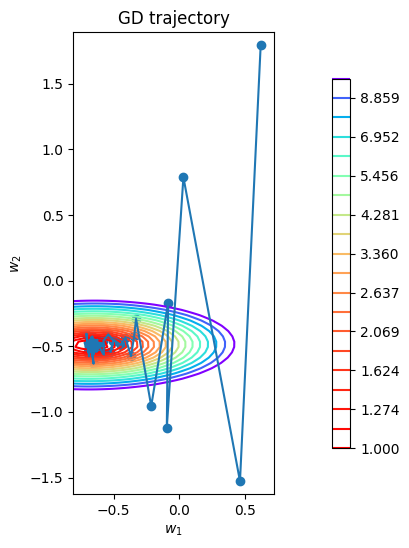

p= 0.2


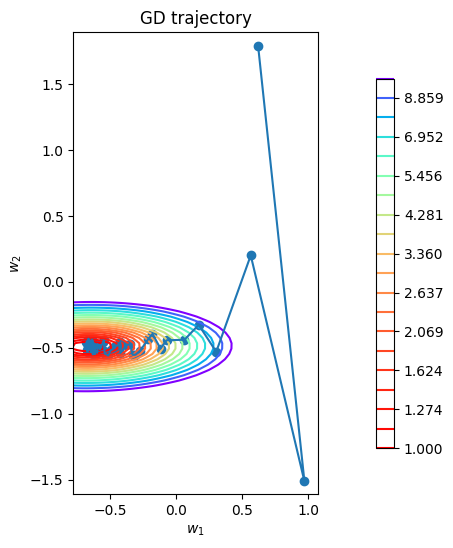

p= 0.3


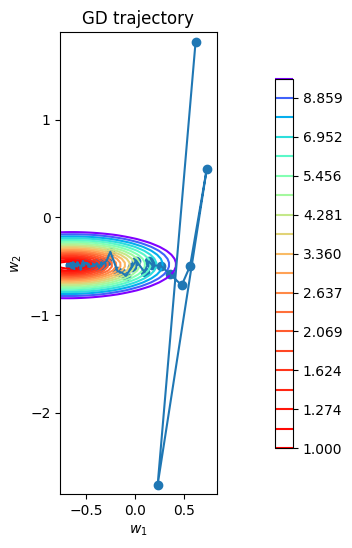

p= 0.4


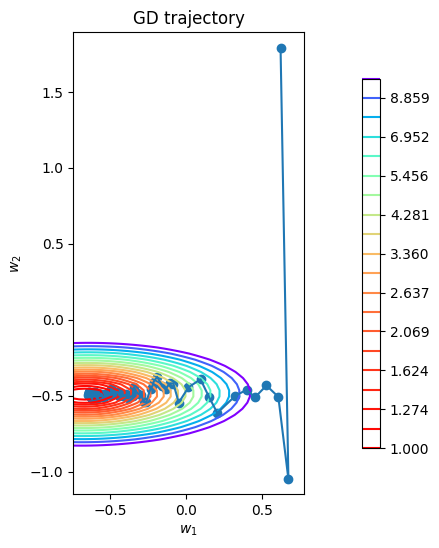

p= 0.5


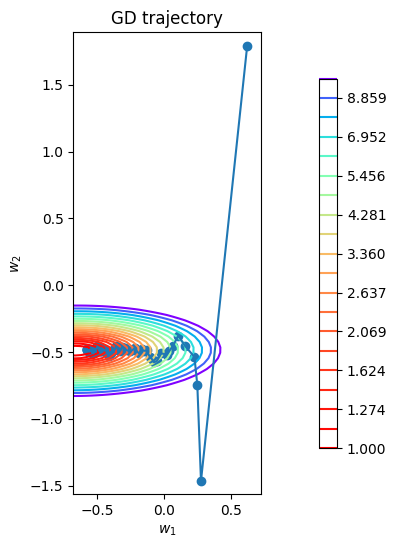

p= 0.6


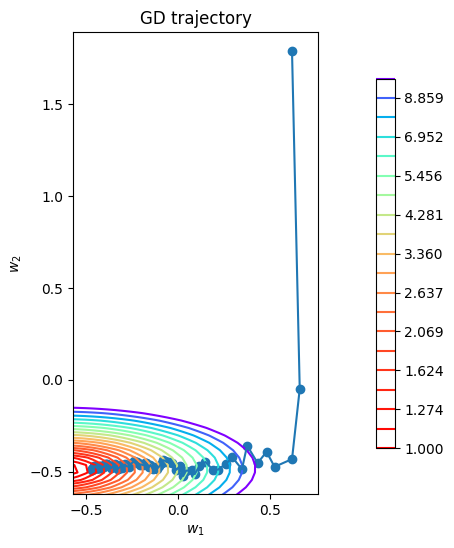

p= 0.7


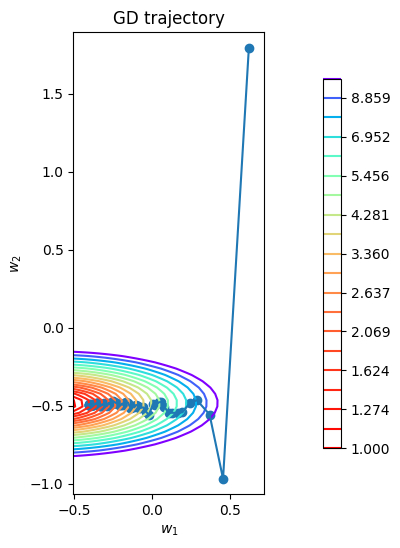

p= 0.8


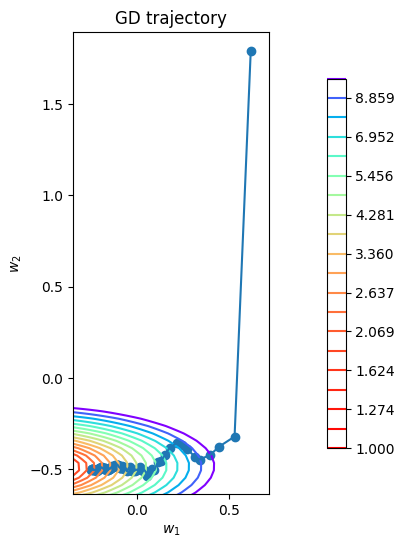

p= 0.9


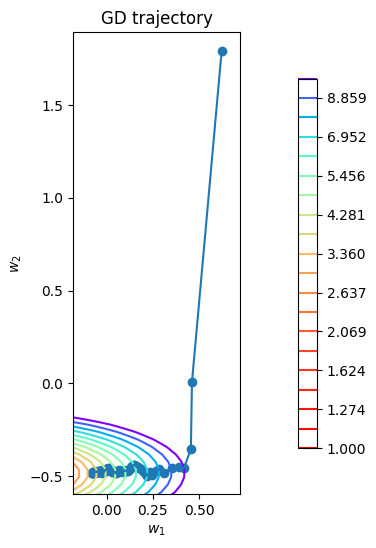

p= 1


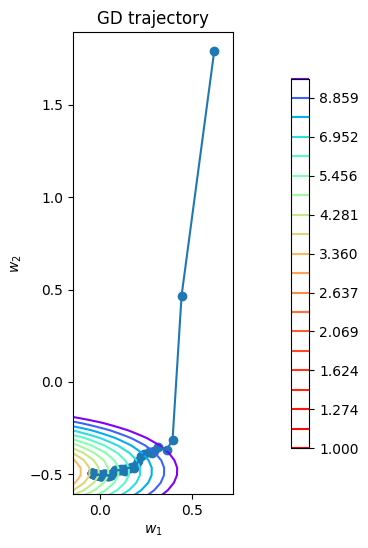

In [15]:
#Takeaways: with p too small, the early movements are too wide and undirected
#near the optimal value, there's a clear direction and steps are reasonably sensible
# with p too large, descent doesn't converge
batch_size = 10
lr = 0.01
p = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
for elem in p:
    print('p=', elem)
    plot_gd(stochastic_gradient_descent(w_init, X, y, loss, lr, batch_size, elem,  100), X, y ,loss)

Compare the convergence of plain gradient descent vs. the stochastic version: plot loss (via `calc_loss`, using the dataset's $x$, $y$, and the weights from each iteration) against iteration number for trajectories from both methods, using the same parameters (`batch_size=10`).


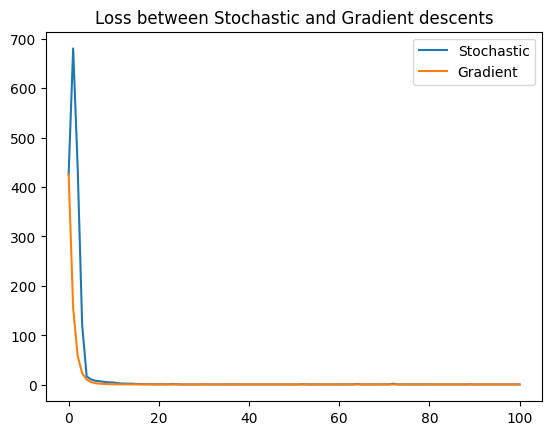

In [16]:
# Takeaway: at early iterations SGD's error is actually higher, but from roughly the 10th iteration onward
# it matches GD's error. Given all of GD's downsides, using SGD here is well justified
batch_size = 10
lr = 0.01
p = 0.1
w_list1 = stochastic_gradient_descent(w_init, X, y, loss, lr, batch_size, p,  100)
w_list2 = gradient_descent(w_init, X, y, loss, lr,  100)
loss_val1, loss_val2 = [], []
for elem in w_list1:
    loss_val1.append(loss.calc_loss(X, y, elem))
for elem in w_list2:
    loss_val2.append(loss.calc_loss(X, y, elem))
x = np.arange(0, 101)
plt.plot(x,loss_val1)
plt.plot(x,loss_val2)
plt.legend(('Stochastic','Gradient'))
plt.title('Loss between Stochastic and Gradient descents')
plt.show()

## Part 2: Linear Regression

Now let's write the `LinearRegression` class itself, using an interface similar to `sklearn`'s.

`fit` finds the weights `w` via `gradient_descent`; `predict` applies the fitted regression to a dataset.

Fill in the `fit` and `predict` methods of the `LinearRegression` class.

`fit` needs to initialize `w`, run `gradient_descent`, and store the final `w` from the trajectory.
`predict` needs to apply the linear model and return the predicted values.

Note the loss object is passed in at init time and stored as `self.loss` -- use it in `fit` for `gradient_descent`.

In [45]:
class LinearRegression:
    def __init__(self, loss: BaseLoss, lr: float = 0.1) -> None:
        self.loss = loss
        self.lr = lr

    def fit(self, X: np.ndarray, y: np.ndarray) -> 'LinearRegression':
        X = np.asarray(X)
        y = np.asarray(y)
        # add a column of ones for the bias/intercept term
        X = np.hstack([X, np.ones([X.shape[0], 1])])
        n_features = X.shape[1]
        w_init = np.random.uniform(-2, 2, (n_features))
        w_list = gradient_descent(w_init, X, y, self.loss, self.lr,  100)
        self.w = w_list[-1]
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        # make sure the regression has been fitted, i.e. fit() was called and set self.w
        assert hasattr(self, "w"), "Linear regression must be fitted first"
        # add a column of ones for the bias/intercept term
        X = np.hstack([X, np.ones([X.shape[0], 1])])
        return np.dot(X, self.w)

Now I have a working linear regression class. Better yet, I can control which loss function it optimizes just by passing a different loss object at init time.

Right now the only loss available is `MSELoss`, but more are coming.

For `MSELoss`, I'd create the regression object like this:

In [46]:
linear_regression = LinearRegression(MSELoss())

Let's try the regression on a real dataset -- the classic UCI automobile dataset:

In [47]:
import pandas as pd

X_raw = pd.read_csv(
    "http://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data",
    header=None,
    na_values=["?"]
)
X_raw.head()
X_raw = X_raw[~X_raw[25].isna()].reset_index()

In [48]:
y = X_raw[25]
X_raw = X_raw.drop(25, axis=1)
X_raw = X_raw.drop('index', axis=1)


As usual, preprocess the dataset so it's ready for linear regression:

* split into train/test
* fill in missing values
* scale numeric features
* encode categorical variables

In [49]:
# standard preprocessing pipeline: impute missing values, encode categoricals, scale numerics
#from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

np.random.seed(0)

cat_features_mask = (X_raw.dtypes == "object").values
X_cat = X_raw[X_raw.columns[cat_features_mask]].fillna("")
X_real = X_raw[X_raw.columns[~cat_features_mask]]

X_no_mis = pd.concat([X_real, X_cat], axis=1)

# one-hot encode the categorical columns
X_dum = pd.get_dummies(X_no_mis, drop_first=True)
X_dum.columns = X_dum.columns.astype(str)

X_train, X_test, y_train, y_test = train_test_split(X_dum, y, random_state=0, shuffle=True)
# impute missing values in the numeric columns with the column mean
cat_features_mask_train = (X_train.dtypes == "object").values
cat_features_mask_test = (X_test.dtypes == "object").values

X_real_train = X_train[X_train.columns[~cat_features_mask_train]]
X_real_test = X_test[X_test.columns[~cat_features_mask_test]]

mis_replacer = SimpleImputer(strategy="mean")
X_no_mis_real_train = pd.DataFrame(data=mis_replacer.fit_transform(X_real_train), columns=X_real_train.columns)
X_no_mis_real_test = pd.DataFrame(data=mis_replacer.transform(X_real_test), columns=X_real_test.columns)
print(X_no_mis_real_train.isnull().any().any())# sanity check -- confirm no missing values remain
print(X_no_mis_real_test.isnull().any().any())
# scale features
normalizer = MinMaxScaler()
X_train = normalizer.fit_transform(X_no_mis_real_train)
X_test = normalizer.transform(X_no_mis_real_test)

False
False


Train the linear regression I wrote on the training set.

In [50]:
lr = linear_regression.fit(X_train,y_train)

Compute the fitted regression's error on train and test using `mean_squared_error` from `sklearn.metrics`.

In [51]:
from sklearn.metrics import mean_squared_error

print ("Train: {}".format(mean_squared_error(y_train, lr.predict(X_train))))
print ("Test: {}".format(mean_squared_error(y_test, lr.predict(X_test))))

Train: 5702569.79717526
Test: 13321283.874691999


The model has overfit. As usual in that situation, let's add L2 regularization -- which means writing a new loss class.

MSE with L2 regularization:
$$
Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell (\langle x_i, w \rangle - y_i)^2 + \lambda ||w||^2
$$

Or in matrix form:

$$
Q(w, X, y) = \frac{1}{\ell} || Xw - y ||^2 + \lambda ||w||^2
$$

where $\lambda$ is the regularization coefficient.

The gradient:

$$
\nabla_w Q(w, X, y) = \frac{2}{\ell} X^T(Xw-y) + 2 \lambda w
$$

Implement `MSEL2Loss`, computing the loss and gradient from the formulas above.

Note: the last element of `w` is the bias (`LinearRegression` appends a column of ones to `X` for the intercept), and bias shouldn't be regularized -- so drop the last element of `w` when computing the $\lambda||w||^2$ term in `calc_loss`, and zero it out when computing the $2\lambda w$ term in `calc_grad`.

In [52]:
class MSEL2Loss(BaseLoss):
    def __init__(self, coef: float = 1.):
        """
        :param coef: regularization coefficient (lambda in the formula)
        """
        self.coef = coef

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Computes the loss value
        :param X: np.ndarray of shape (n_objects, n_features). The last feature is the constant column.
        :param y: np.ndarray of shape (n_objects,) -- the true targets
        :param w: np.ndarray of shape (n_features,) -- the linear regression weights. The last weight is the bias.
        :return: a number -- the loss value
        """
        return np.square(np.dot(X,w) - y).mean() + self.coef * (np.sum(np.square(w)) - np.square(w[-1]))


    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Computes the gradient of the loss with respect to weights w
        :param X: np.ndarray of shape (n_objects, n_features) -- the dataset's objects
        :param y: np.ndarray of shape (n_objects,) -- the true targets
        :param w: np.ndarray of shape (n_features,) -- the linear regression weights
        :return: np.ndarray of shape (n_features,) -- the gradient of the loss w.r.t. w
        """

        w[-1] = 0
        return 2 / np.size(y) * np.dot(np.matrix.transpose(X) , (np.dot(X, w) - y)) +  2* self.coef * w

Now I can use the L2-regularized loss in the regression, e.g.:

In [53]:
linear_regression = LinearRegression(MSEL2Loss())

Train the regression with `MSEL2Loss`. Tune the regularization coefficient and try to beat the unregularized model on the test set. Compare the train/test results to the unregularized regression.

In [73]:
coef = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10]
for elem in coef:
    loss1 = MSEL2Loss(elem)
    linear_regression1 = LinearRegression(loss1)
    lr1 = linear_regression1.fit(X_train,y_train)
    print('coefficient:', elem)
    print ("Train Regulization: {}".format(mean_squared_error(y_train, lr1.predict(X_train))))
    print ("Test Regulization: {}".format(mean_squared_error(y_test, lr1.predict(X_test))))
    print('-------------------------------------------------------------------------------')

linear_regression1 = LinearRegression(MSEL2Loss(0.001))
lr1 = linear_regression1.fit(X_train,y_train)
print('Final results with best regularization equal to 0.001 is')
print ("Train : {}".format(mean_squared_error(y_train, lr1.predict(X_train))))
print ("Test : {}".format(mean_squared_error(y_test, lr1.predict(X_test))))

coefficient: 0.001
Train Regulization: 5784654.534973237
Test Regulization: 13331459.81628944
-------------------------------------------------------------------------------
coefficient: 0.005
Train Regulization: 5909971.81434978
Test Regulization: 13784673.690628296
-------------------------------------------------------------------------------
coefficient: 0.01
Train Regulization: 6073278.58184837
Test Regulization: 14343891.604007348
-------------------------------------------------------------------------------
coefficient: 0.05
Train Regulization: 7511603.386905553
Test Regulization: 18677094.273750164
-------------------------------------------------------------------------------
coefficient: 0.1
Train Regulization: 9299845.964185275
Test Regulization: 23443085.085585225
-------------------------------------------------------------------------------
coefficient: 0.5
Train Regulization: 19099578.269334804
Test Regulization: 46580177.01666201
---------------------------------------

The dataset likely has some outliers. Huber Loss is known to handle those well -- away from zero it behaves like Mean Absolute Error and doesn't react to outliers as strongly as MSE does. Let's implement it and try it in the regression.

Huber Loss:

$$
    Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell \phi_\varepsilon (\langle x_i, w \rangle - y_i)
$$
$$
    \phi_\varepsilon(z) = \begin{cases} \frac 1 2 z^2, - \varepsilon < z < \varepsilon, \\\varepsilon (|z| - \frac 1 2 \varepsilon), \text{otherwise} \\ \end{cases}
$$

And its gradient:
$$
    \nabla_w Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell x_i \nabla_z \phi_\varepsilon (\langle x_i, w \rangle - y_i)
$$
$$
    \nabla_z \phi_\varepsilon(z) = \begin{cases} z, - \varepsilon < z < \varepsilon, \\\varepsilon \text{ sign}(z), \text{otherwise} \\ \end{cases}
$$

Implement `HuberLoss`, computing the loss and gradient from the formulas above.

In [74]:
class HuberLoss(BaseLoss):
    def __init__(self, eps: float) -> None:
        """
        :param eps: the epsilon parameter from the Huber loss formula
        """
        self.eps = eps

    def func_huber_loss(self, numb: float) -> float:
        return (abs(numb)<=self.eps)*numb**2/2 + (abs(numb)>self.eps)*self.eps*(abs(numb)-self.eps/2)

    def func_huber_grad(self, numb: float) -> float:
        return (abs(numb)<=self.eps)*numb + (abs(numb)>self.eps)*self.eps*np.sign(numb)

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Computes the loss value
        :param X: np.ndarray of shape (n_objects, n_features) -- the dataset's objects
        :param y: np.ndarray of shape (n_objects,) -- the true targets
        :param w: np.ndarray of shape (n_features,) -- the linear regression weights
        :return: a number -- the loss value
        """
        smth = np.dot(X,w) - y
        myfunc = np.vectorize(self.func_huber_loss)
        return np.mean(myfunc(smth))

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Computes the gradient of the loss with respect to weights w
        :param X: np.ndarray of shape (n_objects, n_features) -- the dataset's objects
        :param y: np.ndarray of shape (n_objects,) -- the true targets
        :param w: np.ndarray of shape (n_features,) -- the linear regression weights
        :return: np.ndarray of shape (n_features,) -- the gradient of the loss w.r.t. w
        """
        smth = np.dot(X,w) - y
        myfunc = np.vectorize(self.func_huber_grad)
        return np.sum(np.dot(X.T,myfunc(smth)))/np.size(y)

Train the regression with `HuberLoss` and compare train/test results to the `MSELoss` version.

In [84]:
linear_regression = LinearRegression(HuberLoss(100))
lr2 = linear_regression.fit(X_train, y_train)

print ("Train Huber: {}".format(mean_squared_error(y_train, lr2.predict(X_train))))
print ("Test Huber: {}".format(mean_squared_error(y_test, lr2.predict(X_test))))

print ("Train : {}".format(mean_squared_error(y_train, lr.predict(X_train))))
print ("Test : {}".format(mean_squared_error(y_test, lr.predict(X_test))))

Train Huber: 50416186.88701181
Test Huber: 99744125.96550009
Train : 5702569.79717526
Test : 13321283.874691999


Gradient descent is far from the only optimization method out there. Another well-known one is [simulated annealing](https://en.wikipedia.org/wiki/Simulated_annealing). It's not commonly used for optimizing ML models, but it's worth trying out on our linear regression here.

Implement simulated annealing to optimize the MSE of the linear regression.

Compare the result with gradient descent, both by trajectory and by final loss.

```
new_w = old_w + np.random.standard_t(3, size=old_w.shape)
```
Worth experimenting with the distribution's parameter -- the larger it is, the less often new points stray far from the old one.

In [85]:
def my_mse(w,X,y):
    return np.square(np.dot(X,w) - y).mean()
def ne_uveren(X,y,stepen):
    w_list = []
    old_w = np.random.standard_t(stepen, size=X.shape[1])
    w_list.append(old_w)
    coef = 0.5
    new_t = coef
    for i in range(100):
        new_w = old_w + np.random.standard_t(stepen, size=old_w.shape)
        if my_mse(old_w, X, y) >  my_mse(new_w,X, y):
            p = np.exp((my_mse(new_w, X, y) - my_mse(old_w,X,y))/new_t)
            if p < np.random.sample():
                old_w = new_w
        new_t *= coef
        w_list.append(old_w)
    return w_list
stepen = [1,2,3,4,5,6]
for elem in stepen:
    print('degrees of freedom =', elem)
    print ("Train: {}".format(my_mse(ne_uveren(X_train, y_train, elem)[-1],X_train,y_train)))
    print ("Test : {}".format(my_mse(ne_uveren(X_test, y_test, elem)[-1],X_test,y_test)))
    print()
print ("Train MSELoss: {}".format(mean_squared_error(y_train, lr.predict(X_train))))
print ("Test MSELoss: {}".format(mean_squared_error(y_test, lr.predict(X_test))))

degrees of freedom = 1
Train: 181413321.3456382
Test : 284944968.8825439

degrees of freedom = 2
Train: 202237748.73156622
Test : 310926690.41535074

degrees of freedom = 3
Train: 207300050.79665345
Test : 312202442.3998503

degrees of freedom = 4
Train: 205982667.30088693
Test : 312504017.3077931

degrees of freedom = 5
Train: 206471166.2839398
Test : 313173144.41773

degrees of freedom = 6
Train: 206992796.75693834
Test : 313868221.7217369

Train MSELoss: 5702569.79717526
Test MSELoss: 13321283.874691999


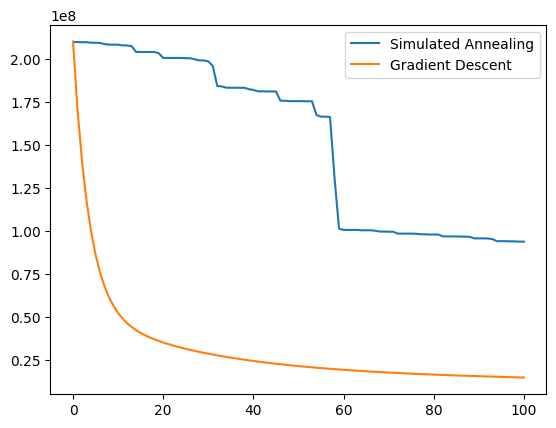

In [86]:
loss = MSELoss()
w_list1 = ne_uveren(X_train, y_train, 1)
w_init = np.random.uniform(-2, 2, (X_train.shape[1]))
w_list2 = gradient_descent(w_init, X_train, y_train, loss, 0.01,  100)
loss_val1, loss_val2 = [], []
for elem in w_list1:
    loss_val1.append(my_mse(elem,X_train, y_train))
for elem in w_list2:
    loss_val2.append(loss.calc_loss(X_train, y_train, elem))
x = np.arange(0, 101)
plt.plot(x,loss_val1)
plt.plot(x,loss_val2)
plt.legend(('Simulated Annealing','Gradient Descent'))
plt.show()